PART II: Deep Learning Classification Task (Default Dataset)

Setup & Imports

In [1]:
!pip install uv && uv pip install ISLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 62.7 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 56 packages in 1.71s
Prepared 9 packages in 485ms
Installed 9 packages in 21ms
 + autograd-gamma==0.5.0
 + formulaic==1.2.1
 + interface-meta==2.0.1
 + islp==0.4.1
 + lifelines==0.30.3
 + lightning-utilities==0.15.3
 + pygam==0.12.0
 + pytorch-lightning==2.6.1
 + torchmetrics==1.9.0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_auc_score, roc_curve,
                             classification_report,
                             ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

print("✅ All packages loaded.")
print(f"   TensorFlow : {tf.__version__}")

✅ All packages loaded.
   TensorFlow : 2.20.0


I. Data Preparation and Exploration

A. Dataset Loading and Inspection

In [10]:
Default = load_data('Default')

print("Dataset Dimensions:", Default.shape)
print("\nData Types:")
print(Default.info())

print("\nSummary Statistics:")
display(Default.describe(include='all'))

Dataset Dimensions: (10000, 4)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   default  10000 non-null  category
 1   student  10000 non-null  category
 2   balance  10000 non-null  float64 
 3   income   10000 non-null  float64 
dtypes: category(2), float64(2)
memory usage: 176.2 KB
None

Summary Statistics:


,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729272


B. Data Preprocessing

In [11]:
# Encode categorical variables (Yes/No to 1/0)
# USING .astype(int) TO FIX THE NEURAL NETWORK CATEGORY ERROR
Default['default'] = (Default['default'] == 'Yes').astype(int)
Default['student'] = (Default['student'] == 'Yes').astype(int)

# Define predictors (X) and response variable (y)
X = Default[['student', 'balance', 'income']]
y = Default['default']

# Train-test splitting (80% train, 20% test, stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Standardize/normalize predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert targets to standard numpy arrays for Keras
y_train_arr = np.asarray(y_train).astype('float32')
y_test_arr  = np.asarray(y_test).astype('float32')

print("First 5 scaled training observations:")
display(X_train_scaled[:5])

First 5 scaled training observations:


array([[ 1.54637236, -0.01806127, -0.33114027],
       [-0.64667477, -1.68747968,  2.19402331],
       [-0.64667477, -0.12391677, -0.28827355],
       [-0.64667477,  0.15566999,  0.99242027],
       [ 1.54637236,  0.44948476, -1.6731921 ]])

II. Logistic Regression Model

A. Model Construction & B. Performance Evaluation

Logistic Regression Results:
Accuracy: 0.9730
ROC-AUC:  0.9484


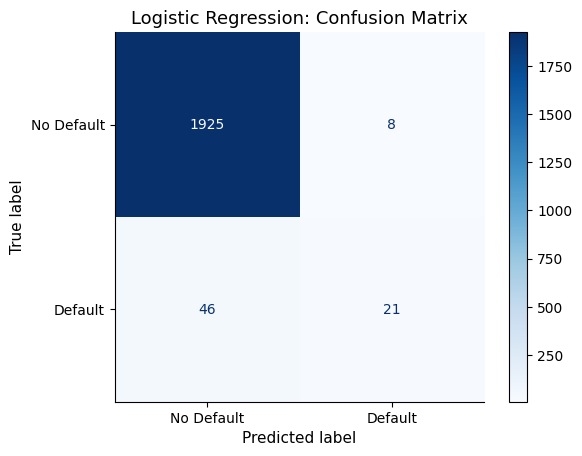

In [12]:
# Fit linear logistic regression model
log_model = LogisticRegression(random_state=SEED)
log_model.fit(X_train_scaled, y_train_arr)

# Predictions
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate Performance
log_eval = {
    "Accuracy": accuracy_score(y_test_arr, log_pred),
    "ROC-AUC": roc_auc_score(y_test_arr, log_prob)
}

print("Logistic Regression Results:")
print(f"Accuracy: {log_eval['Accuracy']:.4f}")
print(f"ROC-AUC:  {log_eval['ROC-AUC']:.4f}")

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_arr, log_pred), display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Logistic Regression: Confusion Matrix")
plt.grid(False)
plt.show()

III. Neural Network Model

A. Neural Network Architecture

In [13]:
# Construct neural network with one hidden layer, 10 hidden units, and dropout
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(10, activation='relu'),       # Hidden layer: 10 units, ReLU activation
    layers.Dropout(0.2),                       # Dropout regularization to prevent overfitting
    layers.Dense(1, activation='sigmoid')      # Output layer: 1 unit, Sigmoid activation for binary classification
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

B. Model Training and Evaluation

Neural Network Results:
Accuracy: 0.9730
ROC-AUC:  0.9472


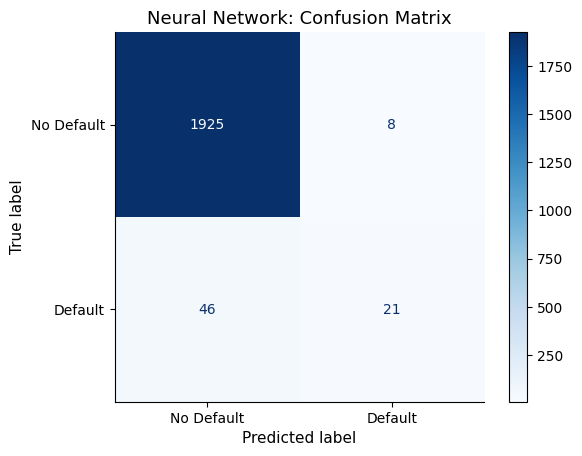

In [14]:
# Train the model with an EarlyStopping callback to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train_arr,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
nn_prob = nn_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_prob > 0.5).astype(int)

# Evaluate Performance
nn_eval = {
    "Accuracy": accuracy_score(y_test_arr, nn_pred),
    "ROC-AUC": roc_auc_score(y_test_arr, nn_prob)
}

print("Neural Network Results:")
print(f"Accuracy: {nn_eval['Accuracy']:.4f}")
print(f"ROC-AUC:  {nn_eval['ROC-AUC']:.4f}")

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_arr, nn_pred), display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Neural Network: Confusion Matrix")
plt.grid(False)
plt.show()

IV. Comparative Analysis and Interpretation


--- Final Model Comparison ---


,Model,Accuracy,ROC-AUC
0,Linear Logistic Regression,0.973,0.9484
1,Neural Network,0.973,0.9472


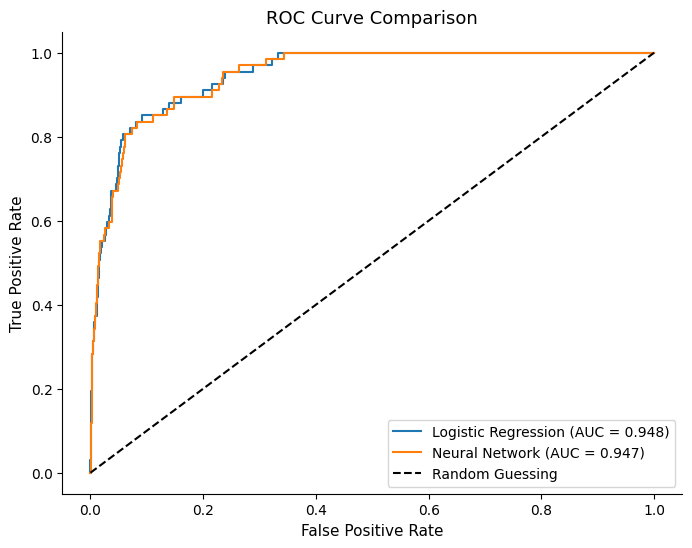

In [15]:
# Compile the metrics into a single comparison table
comparison_df_part2 = pd.DataFrame({
    'Model': ['Linear Logistic Regression', 'Neural Network'],
    'Accuracy': [log_eval['Accuracy'], nn_eval['Accuracy']],
    'ROC-AUC': [log_eval['ROC-AUC'], nn_eval['ROC-AUC']]
})

print("\n--- Final Model Comparison ---")
display(comparison_df_part2.round(4))

# Plot ROC Curves for both models side-by-side
fpr_log, tpr_log, _ = roc_curve(y_test_arr, log_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test_arr, nn_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_eval['ROC-AUC']:.3f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {nn_eval['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()